This notebook computes:

- PDFs of $\|\mathbf{u}\|$, $\zeta/f$, EKE, and KE,
- KE and EKE spectrum.

For each version and reconstruction methods.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cmocean.cm as cmo
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.signal import welch
import pyinterp
import xarray as xr

In [ ]:
swot_ds = xr.open_zarr("./data/SWOT_L3_Expert_v3_0_pass003_pass016_cg.zarr")

In [5]:
swot_ds["uvg"] = np.sqrt(swot_ds.ugos_filtered**2 + swot_ds.vgos_filtered**2)
swot_ds["uvcg_mb"] = np.sqrt(swot_ds.ucg_mb**2 + swot_ds.vcg_mb**2)
swot_ds["uvcg_gw"] = np.sqrt(swot_ds.ucg_gw**2 + swot_ds.vcg_gw**2)
swot_ds["uvcg_fp"] = np.sqrt(swot_ds.ucg_fp**2 + swot_ds.vcg_fp**2)

In [6]:
method_names = ["Geostrophy", "Minimization-based", "Gradient-wind", "Fixed-point"]


def get_da(ds, varnames):
    return xr.concat(
        [ds[varname] for varname in varnames], 
        dim=xr.Variable("reconstruction", method_names), coords="different", compat="equals"
    )

In [7]:
speed_da = get_da(swot_ds, ["uvg", "uvcg_mb", "uvcg_gw", "uvcg_fp"])
rv_da = get_da(swot_ds, ["nrv_g", "nrv_cg_mb", "nrv_cg_gw", "nrv_cg_fp"])
eke_da = get_da(swot_ds, ["eke_g", "eke_cg_mb", "eke_cg_gw", "eke_cg_fp"])
ke_da = get_da(swot_ds, ["ke_g", "ke_cg_mb", "ke_cg_gw", "ke_cg_fp"])

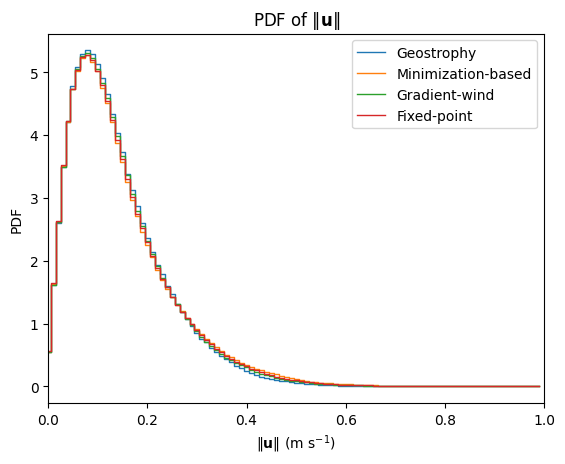

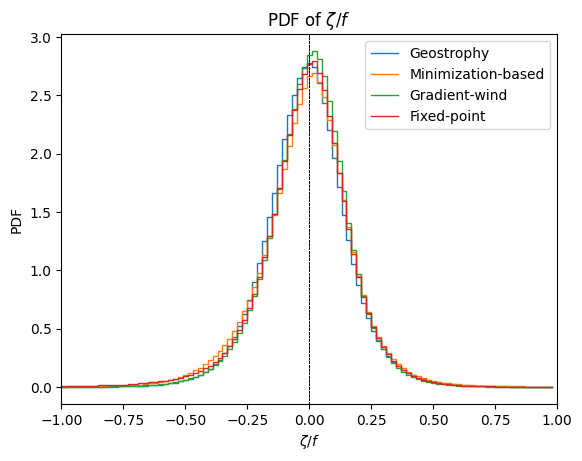

/var/folders/xc/bksmt58x2nq8jshz2jbf9b_m0000gn/T/ipykernel_2983/3437925690.py:37: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(lims[var_name])


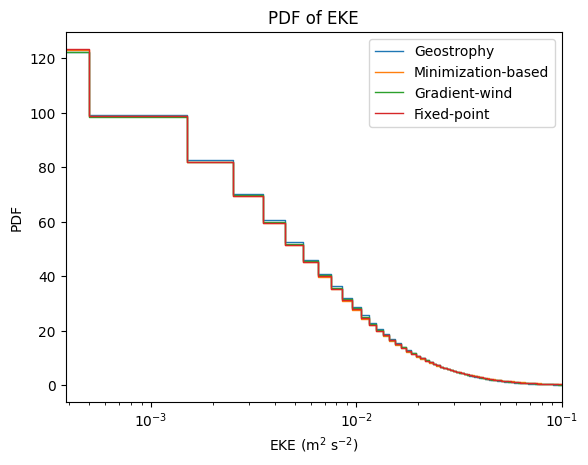

/var/folders/xc/bksmt58x2nq8jshz2jbf9b_m0000gn/T/ipykernel_2983/3437925690.py:37: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(lims[var_name])


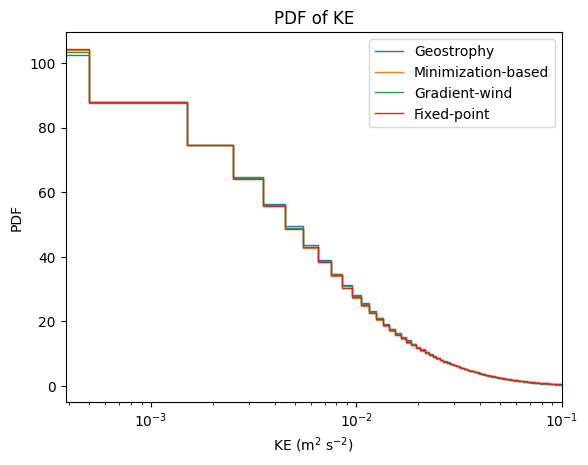

In [8]:
variables = {
    "$\\|\\mathbf{u}\\|$": speed_da,
    "$\\zeta/f$": rv_da,
    "EKE": eke_da,
    "KE": ke_da
}
units = {
    "$\\|\\mathbf{u}\\|$": "m s$^{-1}$",
    "$\\zeta/f$": None,
    "EKE": "m$^2$ s$^{-2}$",
    "KE": "m$^2$ s$^{-2}$"
}
lims = {
    "$\\|\\mathbf{u}\\|$": (0, 1),
    "$\\zeta/f$": (-1, 1),
    "EKE": (0, 0.1),
    "KE": (0, 0.1)
}
colors = ["C0", "C1", "C2", "C3"]

for var_name, da in variables.items():
    fig, ax = plt.subplots()

    for i, method in enumerate(da.reconstruction.values):
        data = da.sel(reconstruction=method).values.ravel()

        hist, bin_edges = np.histogram(data, bins=100, range=lims[var_name], density=True)

        line, = ax.step(bin_edges[:-1], hist, color=colors[i], label=method, linewidth=1, where="mid")

        if var_name == "$\\zeta/f$":
            ax.axvline(0, color="k", linestyle="--", linewidth=0.5)

        if var_name == "EKE" or var_name == "KE":
            ax.set_xscale("log")

    ax.set_xlim(lims[var_name])
    
    xlabel = f"{var_name} ({units[var_name]})" if units[var_name] else var_name
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")

    ax.legend()

    ax.set_title(f"PDF of {var_name}")

    plt.show()

## Along-track wavenumber spectra

In [9]:
psd_path = Path("./data/psd.npz")

if psd_path.exists():
    data = np.load(psd_path)
    freqs = data["freqs"]
    mean_ke_spectra = {}
    mean_eke_spectra = {}
    for method_name in method_names:
        mean_ke_spectra[method_name] = data[f"Aviso_{method_name}_ke"]
        mean_eke_spectra[method_name] = data[f"Aviso_{method_name}_eke"]
else:
    expert_003_ds = xr.open_zarr("./data/SWOT_L3_Expert_v3_0_pass003_cg.zarr")
    expert_016_ds = xr.open_zarr("./data/SWOT_L3_Expert_v3_0_pass016_cg.zarr")

    all_ds = [expert_003_ds, expert_016_ds]
    nperseg = min(ds.sizes["num_lines"] for ds in all_ds)
    dx = 2.0

    def compute_ke_spectrum(ds, anomaly=False, dx=dx, nperseg=nperseg):
        """Along-track KE wavenumber spectrum: E(k) = (PSD(u) + PSD(v)) / 2."""
        u_varnames = ["ugos_filtered", "ucg_mb", "ucg_gw", "ucg_fp"]
        v_varnames = ["vgos_filtered", "vcg_mb", "vcg_gw", "vcg_fp"]
        if anomaly:
            u_varnames = ["ugosa_filtered", "ucga_mb", "ucga_gw", "ucga_fp"]
            v_varnames = ["vgosa_filtered", "vcga_mb", "vcga_gw", "vcga_fp"]

        filled_fields = {}
        for varname in u_varnames + v_varnames:
            fields = []
            for t in range(ds.sizes["cycle_num"]):
                field = ds.isel(cycle_num=t)[varname].transpose("num_pixels", "num_lines").values
                _, _ = pyinterp.fill.gauss_seidel(field)
                fields.append(field)
            filled_fields[varname] = np.stack(fields, axis=0)

        results = {}
        for i, (u_varname, v_varname) in enumerate(zip(u_varnames, v_varnames)):
            psds = []
            for varname in [u_varname, v_varname]:
                field = filled_fields[varname]
                field = field.reshape(-1, field.shape[-1])
                f, psd = welch(
                    field, fs=1.0 / dx, nperseg=nperseg, window="hann",
                    detrend="linear", axis=1, scaling="density",
                )
                psds.append(np.mean(psd, axis=0))
            if len(psds) == 2:
                results[method_names[i]] = (f[1:], ((psds[0] + psds[1]) / 2)[1:])
        return results

    per_pass_spectra = {}
    for label, ds in zip(
        ["expert_003", "expert_016"], all_ds
    ):
        per_pass_spectra[label] = {
            "ke": compute_ke_spectrum(ds),
            "eke": compute_ke_spectrum(ds, anomaly=True),
        }

    freqs = per_pass_spectra["expert_003"]["ke"]["Geostrophy"][0]

    spectra_by_version = {
        "Aviso": ["expert_003", "expert_016"],
    }

    mean_ke_spectra = {}
    mean_eke_spectra = {}
    for version, pass_labels in spectra_by_version.items():
        mean_ke_spectra[version] = {}
        mean_eke_spectra[version] = {}
        for method_name in method_names:
            for var_key, target in [("ke", mean_ke_spectra), ("eke", mean_eke_spectra)]:
                psds = [per_pass_spectra[pl][var_key][method_name][1] for pl in pass_labels]
                target[version][method_name] = np.mean(psds, axis=0)

    kwargs = {"freqs": freqs}
    for version, method_psd_dict in mean_ke_spectra.items():
        for method_name, psd in method_psd_dict.items():
            kwargs[f"{version}_{method_name}_ke"] = psd
    for version, method_psd_dict in mean_eke_spectra.items():
        for method_name, psd in method_psd_dict.items():
            kwargs[f"{version}_{method_name}_eke"] = psd
    np.savez(psd_path, **kwargs)

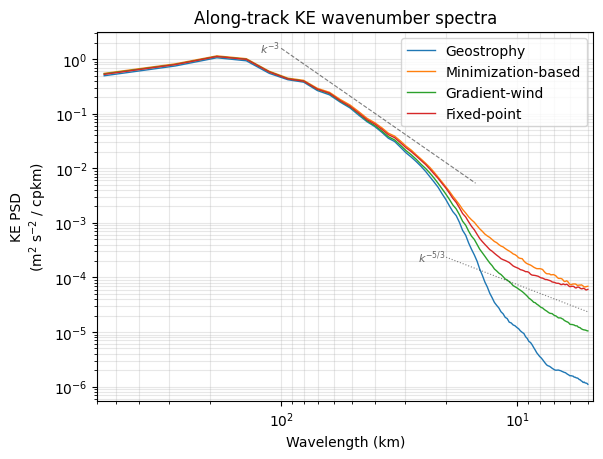

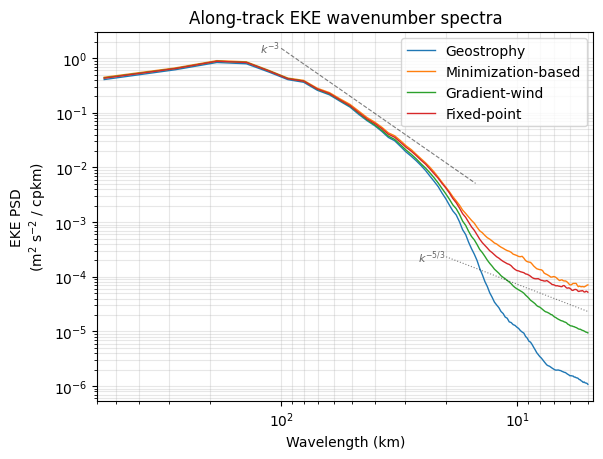

In [ ]:
colors = ["C0", "C1", "C2", "C3"]

mask = ((1 / freqs) > 5) & ((1 / freqs) < 600)
_freqs = freqs[mask]

for var_spectra, mean_spectra in zip(["KE", "EKE"], [mean_ke_spectra, mean_eke_spectra]):
    fig, ax = plt.subplots()

    for i, (method, psd) in enumerate(mean_spectra.items()):
        _psd = psd[mask]
        line, = ax.loglog(1.0 / _freqs, _psd, color=colors[i], label=method, lw=1)

    # reference slopes
    all_masked_psds = np.array([p[mask] for p in mean_spectra.values()])
    ref_specs = [
        # (slope, linestyle, label, anchor_wl_km, offset_factor, wl_range)
        (-3,   "--", "$k^{-3}$",   80, 2.0, (100, 15)),
        (-5/3, ":",  "$k^{-5/3}$", 10, 0.3, (20, 5)),
    ]
    for slope, ls, lbl, anchor_wl, offset, (wl_lo, wl_hi) in ref_specs:
        idx_a = np.argmin(np.abs(1.0 / _freqs - anchor_wl))
        k0 = _freqs[idx_a]
        p0 = all_masked_psds[:, idx_a].max() * offset
        k_ref = np.logspace(np.log10(1 / wl_lo), np.log10(1 / wl_hi), 30)
        ref_psd = p0 * (k_ref / k0) ** slope
        ref, = ax.loglog(1 / k_ref, ref_psd, "k", ls=ls, lw=0.8, alpha=0.5)
        ax.text(1 / k_ref[0], ref_psd[0], f"{lbl} ", fontsize=8, alpha=0.6, va="center", ha="right",)

    ax.set_xlim(600, 4.75)
    ax.grid(True, alpha=0.3, which="both")

    ax.set_ylabel(f"{var_spectra} PSD\n(m$^2$ s$^{{-2}}$ / cpkm)")
    ax.set_xlabel("Wavelength (km)")

    ax.legend()

    ax.set_title(f"Along-track {var_spectra} wavenumber spectra")

    plt.show()

## Joint vorticity–strain PDF

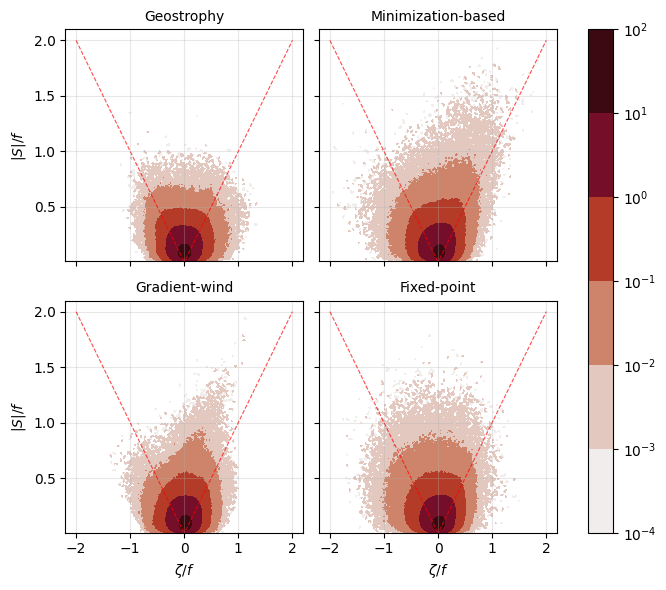

In [15]:
strain_da = get_da(swot_ds, ["strain_g", "strain_cg_mb", "strain_cg_gw", "strain_cg_fp"])

lim = 2
nbins = 150
edges_vort = np.linspace(-lim, lim, nbins + 1)
edges_strain = np.linspace(0, lim, nbins + 1)
centers_vort = (edges_vort[:-1] + edges_vort[1:]) / 2
centers_strain = (edges_strain[:-1] + edges_strain[1:]) / 2

hist_data = np.zeros((len(method_names), nbins, nbins))
for i, method in enumerate(method_names):
    vort = rv_da.sel(reconstruction=method).values.ravel()
    strn = strain_da.sel(reconstruction=method).values.ravel()
    valid = ~(np.isnan(vort) | np.isnan(strn))
    h, _, _ = np.histogram2d(vort[valid], strn[valid], bins=[edges_vort, edges_strain], density=True)
    hist_data[i] = h

hist_da = xr.DataArray(
    hist_data,
    dims=["reconstruction", "$\\zeta/f$", "$|S|/f$"],
    coords={
        "reconstruction": method_names,
        "$\\zeta/f$": centers_vort,
        "$|S|/f$": centers_strain,
    },
).where(lambda x: x > 0)

fg = hist_da.plot.contourf(
    x="$\\zeta/f$", y="$|S|/f$", col="reconstruction", col_wrap=2,
    norm=LogNorm(), cmap=cmo.amp
)

fg.set_titles("{value}")

# OW = 0 boundary ; grid
x_ref = np.linspace(-lim, lim, 100)
for ax in fg.axs.flat:
    ax.plot(x_ref, np.abs(x_ref), "r--", lw=0.8, alpha=0.7)
    ax.grid(True, alpha=0.3)

plt.show()